# 01 Dqn Implementation

## 📚 Learning Objectives

By completing this notebook, you will:
- Implement DQN with experience replay and target network
- Train on simple RL environments

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Basic NumPy/Pandas (when applicable)

---

## Official Structure Reference

This notebook belongs to **Course 09, Unit 3**.

---


## Lesson Brief

This lesson introduces **Deep Q-Networks (DQN)** as the extension of Q-learning to larger or continuous observation spaces.

Students will see why a neural network is used instead of a table, and why replay buffers and target networks are needed for stability.

Why this matters: DQN is often the first deep RL algorithm students encounter in practice.

It links tabular RL ideas to neural-network-based learning.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Johnny Code - "Simply Explaining Deep Q-Learning/Deep Q-Network (DQN)"**:
[Watch on YouTube](https://www.youtube.com/watch?v=EUrWGTCGzlA)

Why this pick:
- practical code-centered explanation.
- Connects Q-learning, epsilon-greedy, target networks, and replay buffers cleanly.
- Excellent bridge from tabular Q-learning to deep RL.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Replay buffer: stored experiences reused for learning.
- Target network: a slower reference network used to stabilize targets.
- Mini-batch: a small sampled training batch.
- Function approximator: a neural network replacing the table.
- Bellman target: reward plus estimated future value used in the update.

### Quick Check
- Why does DQN need replay?
- Why use a target network?
- What does DQN solve that tabular methods cannot?
- Why is DQN still conceptually part of the Q-learning family?

### Common Mistakes
- Focusing on network code but missing the algorithm idea.
- Thinking deep RL is unrelated to Q-learning.
- Ignoring stability as the main challenge.
- Forgetting that the network is approximating the same kind of action values learned in tabular Q-learning.


## Big Idea

DQN extends Q-learning by replacing the Q-table with a neural network.

This matters when the observation space is too large or continuous for a simple
lookup table.

## What to watch for

As you read the implementation, track four moving parts:

- Q-network
- target network
- replay buffer
- epsilon-greedy exploration

## Why DQN is different from tabular Q-learning

Tabular Q-learning stores one value per state-action pair.

DQN instead learns a function:

\[
Q_\theta(s,a)
\]

That makes it more scalable, but also less stable without extra tricks.

## Stability reminders

DQN is more delicate than Unit 2 methods.

Without replay buffers and target networks, training can become unstable because
both the data distribution and the learning target keep changing.

## Reading strategy

Do not try to memorize every line at once.

Instead, read the code in this order:

1. network definition
2. action selection
3. replay storage
4. Bellman target
5. optimizer step

## 🌍 Real-World Worked Example — CartPole with DQN

**Industry context:**
- Boston Dynamics uses policy gradient variants (similar to DQN) for robot balance control
- Tesla's Autopilot reward signal includes smooth lane-keeping (like CartPole balance)

We train a **DQN agent** to balance a pole on a cart using raw observations from OpenAI Gymnasium.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


Episode   0 | Avg reward (last 30): 16.0 | ε=0.995


Episode  30 | Avg reward (last 30): 21.0 | ε=0.856


Episode  60 | Avg reward (last 30): 27.9 | ε=0.737


Episode  90 | Avg reward (last 30): 23.8 | ε=0.634


Episode 120 | Avg reward (last 30): 27.8 | ε=0.545


Episode 150 | Avg reward (last 30): 37.1 | ε=0.469


Episode 180 | Avg reward (last 30): 34.8 | ε=0.404


Episode 210 | Avg reward (last 30): 47.7 | ε=0.347


Episode 240 | Avg reward (last 30): 40.5 | ε=0.299


Episode 270 | Avg reward (last 30): 84.1 | ε=0.257


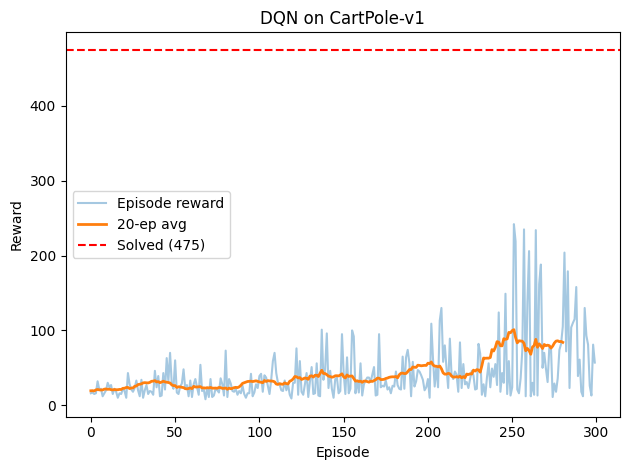

In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import torch, torch.nn as nn, torch.optim as optim
# Load a library so you can use its ready-made functions and types below.
import gymnasium as gym
# Load a library so you can use its ready-made functions and types below.
import numpy as np, random, collections, matplotlib.pyplot as plt

# Call a PyTorch API (tensor/module/training-related).
torch.manual_seed(42); np.random.seed(42)

# Save a value in a name so the next lines can read it.
env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
# Class `DQN` (what it does): defines an object blueprint (attributes + methods); read the indented block to see each part.
class DQN(nn.Module):
    # Function `__init__` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, obs, act.
    def __init__(self, obs=4, act=2):
        # Execute: super().__init__()
        super().__init__()
        # Save a value in a name so the next lines can read it.
        self.net = nn.Sequential(
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(obs,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128,128), nn.ReLU(),
            # Call a PyTorch API (tensor/module/training-related).
            nn.Linear(128, act)
        # Close the parentheses opened earlier (end this function call / grouping).
        )
    # Function `forward` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: self, x.
    def forward(self, x): return self.net(x)

# Create or update the greedy policy array (one int action id per state).
policy_net = DQN(); target_net = DQN()
# Execute: target_net.load_state_dict(policy_net.state_dict())
target_net.load_state_dict(policy_net.state_dict())
# Save a value in a name so the next lines can read it.
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
# Another assignment—same idea: store a value for the lines below.
memory  = collections.deque(maxlen=10000)
# Set discount factor gamma used inside r + gamma * V(s') targets.
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
# Save a value in a name so the next lines can read it.
BATCH   = 64; rewards_ep = []

# Start a loop: repeat the indented block once per item in the sequence.
for episode in range(300):
    # Save a value in a name so the next lines can read it.
    obs,_ = env.reset(); total_r = 0
    # Start a loop: repeat the indented block once per item in the sequence.
    for t in range(500):
        # If the condition is True, run the indented block under this line.
        if random.random() < EPS:
            # Save a value in a name so the next lines can read it.
            action = env.action_space.sample()
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        # Another assignment—same idea: store a value for the lines below.
        obs2, r, done, trunc, _ = env.step(action)
        # Add one new item to the end of a list (the list grows in place).
        memory.append((obs, action, r, obs2, done or trunc))
        # Save a value in a name so the next lines can read it.
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        # If the condition is True, run the indented block under this line.
        if len(memory) >= BATCH:
            # Save a value in a name so the next lines can read it.
            batch = random.sample(memory, BATCH)
            # Another assignment—same idea: store a value for the lines below.
            s,a,r_b,s2,d = zip(*batch)
            # Another assignment—same idea: store a value for the lines below.
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            # Another assignment—same idea: store a value for the lines below.
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            # Another assignment—same idea: store a value for the lines below.
            D=torch.tensor(d).float()
            # Another assignment—same idea: store a value for the lines below.
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            # Safely open/use a resource; Python cleans up when the block ends.
            with torch.no_grad():
                # Save a value in a name so the next lines can read it.
                Q_next = target_net(S2).max(1)[0]
            # Another assignment—same idea: store a value for the lines below.
            Q_target = R + GAMMA*Q_next*(1-D)
            # Another assignment—same idea: store a value for the lines below.
            loss = nn.MSELoss()(Q_pred, Q_target)
            # Execute: opt.zero_grad(); loss.backward(); opt.step()
            opt.zero_grad(); loss.backward(); opt.step()
        # If the condition is True, run the indented block under this line.
        if done or trunc: break
    # Save a value in a name so the next lines can read it.
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    # Add one new item to the end of a list (the list grows in place).
    rewards_ep.append(total_r)
    # If the condition is True, run the indented block under this line.
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    # If the condition is True, run the indented block under this line.
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

# Execute: env.close()
env.close()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(rewards_ep, alpha=0.4, label="Episode reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(np.convolve(rewards_ep, np.ones(20)/20, 'valid'), label="20-ep avg", lw=2)
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("DQN on CartPole-v1"); plt.xlabel("Episode"); plt.ylabel("Reward")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.axhline(475, color='red', linestyle='--', label="Solved (475)"); plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout(); plt.show()


## CartPole step-through (GIF + slider)

Same **Gymnasium** `reset` → `step` loop as Unit 1, shown as **pixels**. Policy is **random** so this cell stays lightweight; after you understand the actor’s action distribution, try swapping in a greedy policy from your trained network as an extension.

In [ ]:
%pip install ipywidgets pillow -q

import pathlib
import sys

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError("Could not find course09_step_viz.py — run from inside Course 09.")

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz

env_vis = gym.make("CartPole-v1", render_mode="rgb_array")


def random_policy(obs, step):
    return int(env_vis.action_space.sample())


frames, total_r, term, trunc = cs9viz.collect_rollout_frames(
    env_vis, random_policy, max_steps=100, seed=0
)
env_vis.close()

print(f"{len(frames)} frames | return={total_r:.1f} | term={term} | trunc={trunc}")
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="CartPole-v1 timestep")

## 📝 Summary

In this notebook, you learned:
- The **DQN algorithm**: approximating Q-values with a neural network instead of a table
- **Experience replay**: storing transitions in a replay buffer and sampling random mini-batches to break correlations
- **Target network**: a periodically-updated copy of the Q-network that stabilizes training
- How to set up an **OpenAI Gym** environment loop: observe → act → store → sample → update

**Next steps:** Study advanced DQN variants (Double DQN, Dueling DQN, Prioritized Experience Replay) and policy-gradient methods like PPO in later units.

In [ ]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Papers
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

### State-of-the-art DQN variants power game-playing AI and robotics controllers at Google DeepMind.
"""))


### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


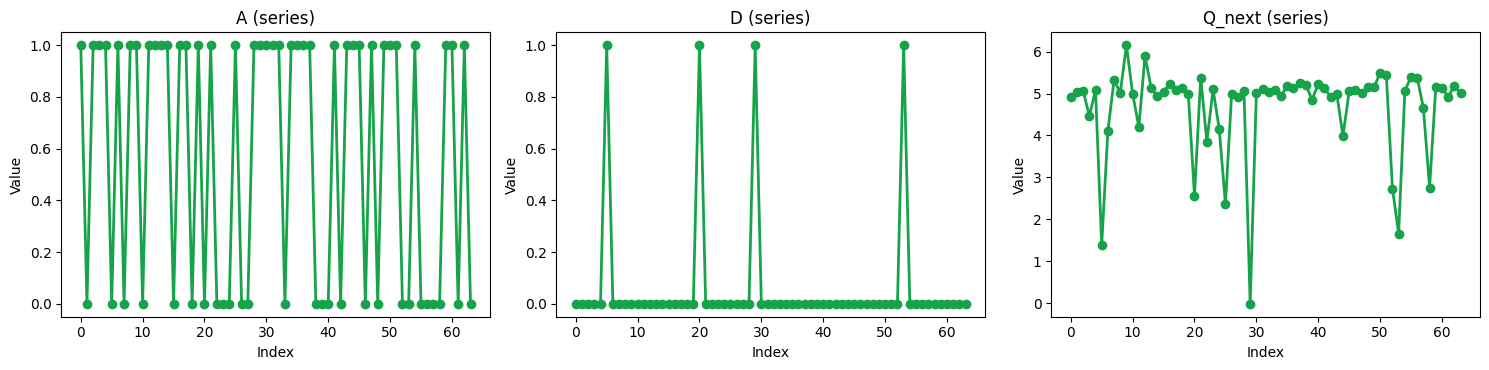

In [2]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** DQN scales Q-learning by replacing the table with a neural network and stabilizing training with replay and target networks.

**If students remember one idea:** Deep RL is not just tabular RL with more code. Stability tricks are essential because the target and the function approximator both move during learning.

**Quick check before moving on:**
- Can you explain why replay buffers reduce harmful correlations in training data?
- Can you describe why a separate target network improves stability?

**Bridge to the next step:** Next, students will study actor-critic methods, which split the learning problem into policy and value roles.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.
